<a href="https://colab.research.google.com/github/olivocdz-cmd/Programacion1/blob/main/Proyecto_an%C3%A1lisis_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('Paquetes importados correctamente')

Paquetes importados correctamente


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving k_capitulos.csv to k_capitulos (5).csv


In [ ]:
df = pd.read_csv('k_capitulos.csv', sep=',', engine='python')

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas disponibles:\n{df.columns.tolist()}')
df.head()

Dimensiones del dataset: (3982, 48)

Columnas disponibles:
['K_01_A', 'K_01_B', 'K_01_C', 'K_01_D', 'K_02', 'K_03', 'K_04', 'K_05', 'K_06', 'K_07', 'K_08', 'K_09', 'K_09_VALOR', 'K_09_TEXTO', 'K_10_A', 'K_10_B', 'K_10_C', 'K_10_D', 'K_10_E', 'K_10_F', 'K_10_G', 'K_10_H', 'K_10_I', 'K_11', 'K_11_A', 'K_11_B', 'K_11_C', 'K_11_D', 'K_11_E', 'K_12_A', 'K_12_B', 'K_12_C', 'K_12_D', 'K_12_E', 'K_12_F', 'K_12_G', 'K_12_H', 'K_12_I', 'K_12_J', 'K_12_K', 'K_12_L', 'K_12_M', 'K_12_N', 'K_12_O', 'DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN']


,K_01_A,K_01_B,K_01_C,K_01_D,K_02,K_03,K_04,K_05,K_06,K_07,...,K_12_J,K_12_K,K_12_L,K_12_M,K_12_N,K_12_O,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN
0,NaN,1.0,NaN,NaN,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7,1,1,1
1,1.0,NaN,NaN,NaN,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,38,3,1,3
2,NaN,NaN,NaN,1.0,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,48,1,1,1
3,1.0,NaN,NaN,NaN,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,99,5,1,5
4,NaN,1.0,NaN,NaN,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,129,1,1,1


In [ ]:
features = ['K_12_A', 'K_12_B', 'K_12_C', 'K_12_D', 'K_12_E', 'K_12_F']
target   = 'K_03'

data = df[features + [target]].copy()

# ── Variable objetivo ────────────────────────────────────────────────────────
# K_03: ¿Ha consumido marihuana en los últimos 12 meses?
#   1 = Sí  → Clase 1 (consumidor reciente)
#   2 = No  → Clase 0 (no consumidor reciente)
#   9 = No contesta → se elimina
data = data[data[target] != 9].copy()
data[target] = data[target].map({1: 1, 2: 0})

# ── Variables explicativas K_12_A–F ─────────────────────────────────────────
# Estas preguntas sobre consecuencias del consumo de marihuana solo se
# formulan a quienes respondieron K_03 = 1. Para los no consumidores el
# valor es NaN por diseño del instrumento, equivalente a 'No' (2).
# Se imputa NaN con 2 (No) y luego se binariza: 1=Sí→1 | 2=No→0
for col in features:
    data[col] = data[col].fillna(2)
    data[col] = data[col].map({1: 1, 2: 0})

print('Valores nulos después de imputación:')
print(data.isnull().sum())

print(f'\nDistribución de la variable objetivo ({target}):')
print(data[target].value_counts())
print(f'\nPorcentaje Clase 1 (consumidor últimos 12 meses):  {data[target].mean()*100:.1f}%')
print(f'Porcentaje Clase 0 (no consumidor últimos 12 meses): {(1-data[target].mean())*100:.1f}%')

Valores nulos después de imputación:
K_12_A    0
K_12_B    0
K_12_C    0
K_12_D    0
K_12_E    0
K_12_F    0
K_03      0
dtype: int64

Distribución de la variable objetivo (K_03):
K_03
0    2754
1    1223
Name: count, dtype: int64

Porcentaje Clase 1 (consumidor últimos 12 meses):  30.8%
Porcentaje Clase 0 (no consumidor últimos 12 meses): 69.2%


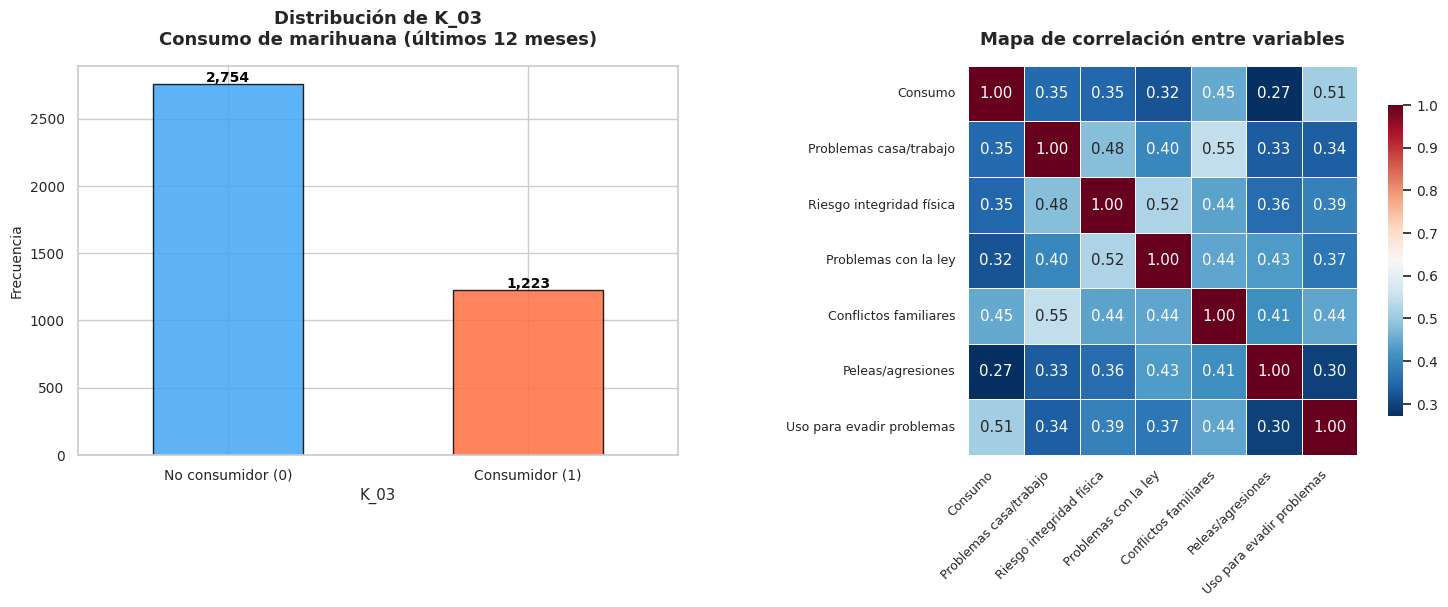

In [42]:
etiquetas = {
    'K_12_A': 'Problemas casa/trabajo',
    'K_12_B': 'Riesgo integridad física',
    'K_12_C': 'Problemas con la ley',
    'K_12_D': 'Conflictos familiares',
    'K_12_E': 'Peleas/agresiones',
    'K_12_F': 'Uso para evadir problemas'
}

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

conteos = data[target].value_counts().sort_index()
bars = conteos.plot(kind='bar', ax=axes[0], color=['#42A5F5', '#FF7043'], edgecolor='black', alpha=0.85)

axes[0].set_title('Distribución de K_03\nConsumo de marihuana (últimos 12 meses)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Frecuencia', fontsize=10)
axes[0].set_xticklabels(['No consumidor (0)', 'Consumidor (1)'], rotation=0, fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

cols_to_plot = [target] + list(etiquetas.keys())
corr_subset = data[cols_to_plot].corr()

labels = ['Consumo'] + [etiquetas.get(c, c) for c in etiquetas.keys()]

sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r',
            ax=axes[1], linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            xticklabels=labels, yticklabels=labels)

axes[1].set_title('Mapa de correlación entre variables', fontsize=13, fontweight='bold', pad=15)

plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('exploratorio_bonito.png', dpi=300, bbox_inches='tight')
plt.show()

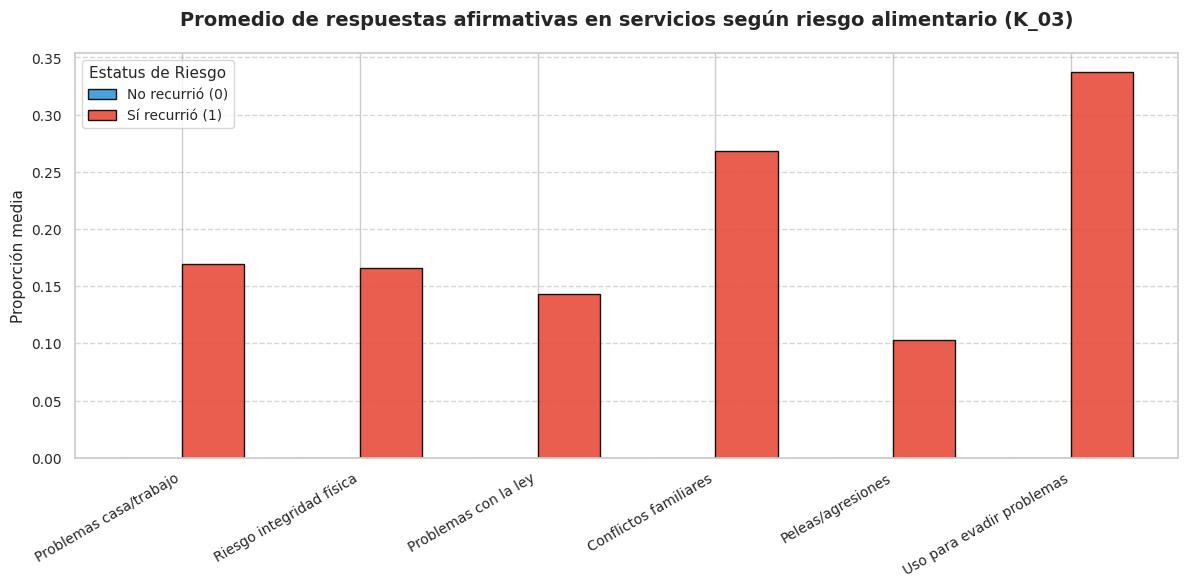

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

prop = data.groupby(target)[features].mean()

prop_df = prop.T.rename(index=etiquetas)


prop_df.plot(kind='bar', ax=ax,
             color=['#3498db', '#e74c3c'],
             edgecolor='black', width=0.7, alpha=0.9)

ax.set_title('Promedio de respuestas afirmativas en servicios según riesgo alimentario (K_03)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Proporción media', fontsize=11)
ax.set_xlabel('')

ax.set_xticklabels(prop_df.index, rotation=30, ha='right', fontsize=10)

ax.legend(['No recurrió (0)', 'Sí recurrió (1)'],
          title="Estatus de Riesgo",
          fontsize=10, title_fontsize=11, frameon=True)


ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('proporciones_servicios.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'--- Dimensiones de los datos ---')
print(f'Entrenamiento: {X_train.shape}')
print(f'Prueba:        {X_test.shape}\n')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'--- Balanceo de clases (SMOTE) ---')
print('Distribución antes de SMOTE:\n', pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print('Distribución después de SMOTE:\n', pd.Series(y_train_bal).value_counts().to_dict())
print('\n¡Preprocesamiento completado exitosamente!')

--- Dimensiones de los datos ---
Entrenamiento: (3181, 6)
Prueba:        (796, 6)

--- Balanceo de clases (SMOTE) ---
Distribución antes de SMOTE:
 {0: 2203, 1: 978}
Distribución después de SMOTE:
 {0: 2203, 1: 2203}

¡Preprocesamiento completado exitosamente!


In [43]:

modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión':   DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100)
}

resultados = {}

for nombre, modelo in modelos.items():

    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test_sc)


    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = {'modelo': modelo, 'predicciones': y_pred, 'accuracy': acc}


    print(f"\n" + "━" * 60)
    print(f" MODELO: {nombre.upper()}")
    print("━" * 60)
    print(f"Precisión Global (Accuracy): {acc:.4%}")
    print("-" * 60)
    print("Reporte de Clasificación detallado:")
    print(classification_report(y_test, y_pred,
                                target_names=['No consumidor (0)', 'Consumidor (1)']))
    print("━" * 60)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MODELO: REGRESIÓN LOGÍSTICA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Precisión Global (Accuracy): 84.2965%
------------------------------------------------------------
Reporte de Clasificación detallado:
                   precision    recall  f1-score   support

No consumidor (0)       0.82      1.00      0.90       551
   Consumidor (1)       1.00      0.49      0.66       245

         accuracy                           0.84       796
        macro avg       0.91      0.74      0.78       796
     weighted avg       0.87      0.84      0.82       796

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MODELO: ÁRBOL DE DECISIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Precisión Global (Accuracy): 84.2965%
------------------------------------------------------------
Reporte de Clasificación detallado:
          

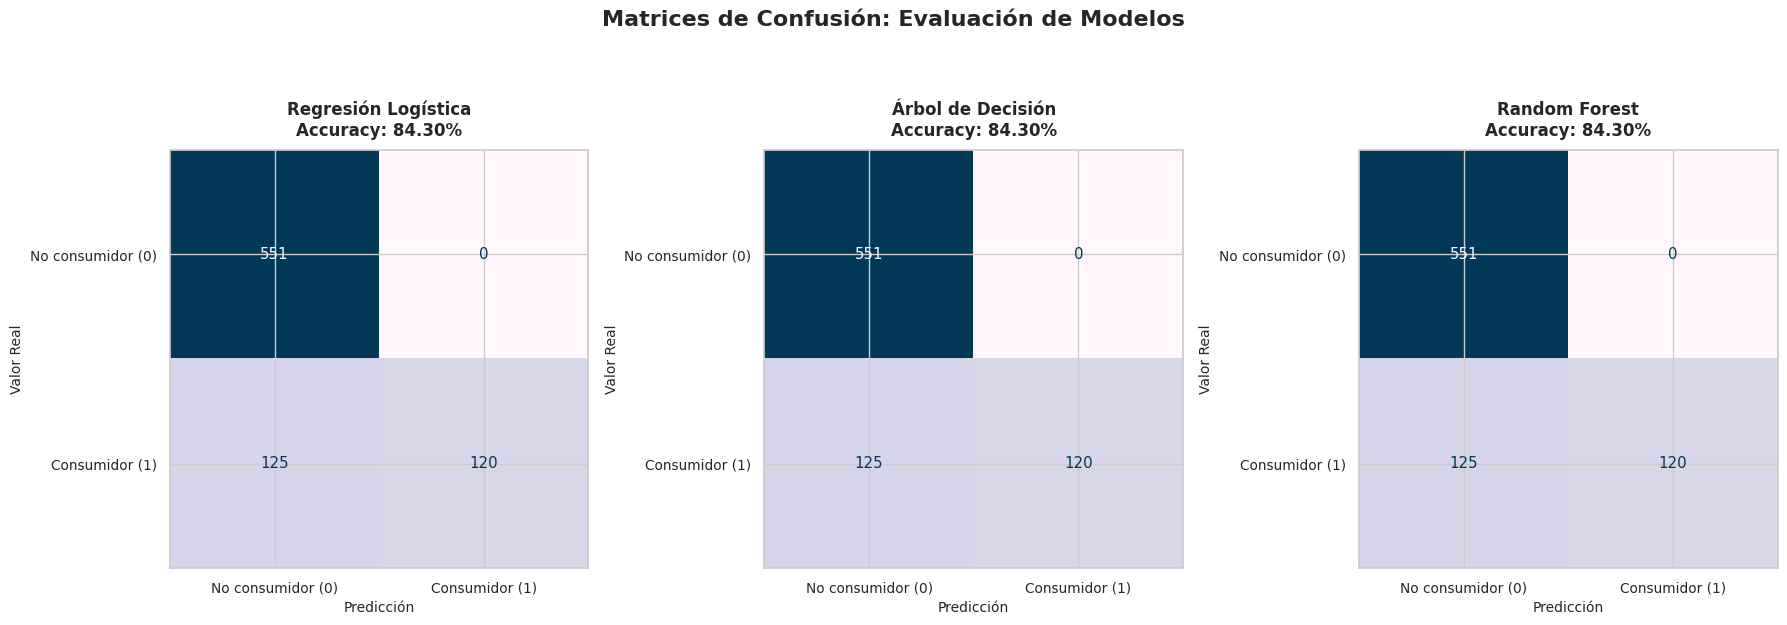

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


for ax, (nombre, res) in zip(axes, resultados.items()):

    cm = confusion_matrix(y_test, res['predicciones'])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No consumidor (0)', 'Consumidor (1)'])

    disp.plot(ax=ax, colorbar=False, cmap='PuBu', values_format='d')

    ax.set_title(f"{nombre}\nAccuracy: {res['accuracy']:.2%}",
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Valor Real', fontsize=10)

plt.suptitle('Matrices de Confusión: Evaluación de Modelos',
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('matrices_confusion_pro.png', dpi=300, bbox_inches='tight')
plt.show()

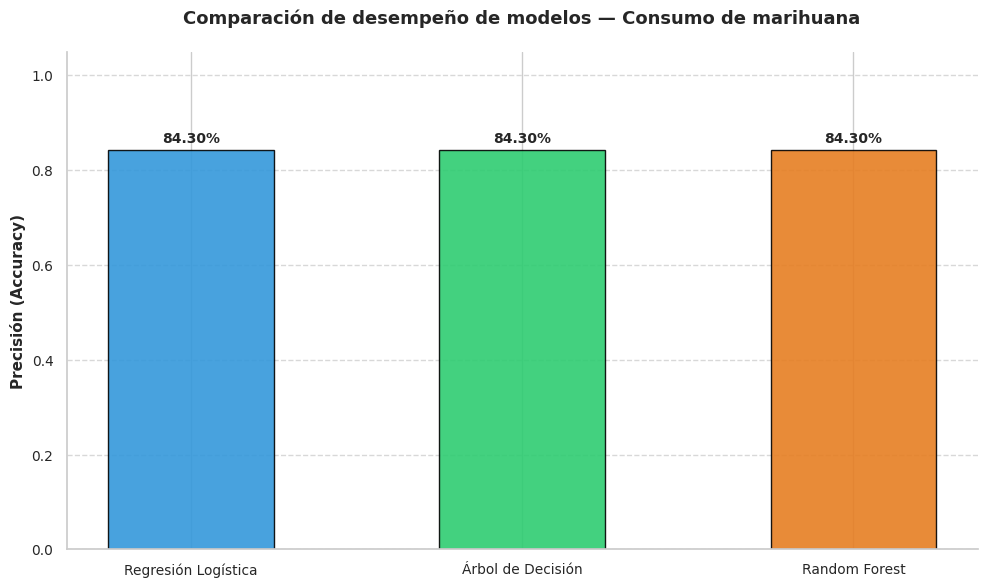

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

nombres    = list(resultados.keys())
accuracies = [res['accuracy'] for res in resultados.values()]

colores    = ['#3498db', '#2ecc71', '#e67e22']

bars = ax.bar(nombres, accuracies, color=colores, edgecolor='black',
              width=0.5, alpha=0.9)

ax.set_ylim(0, 1.05)
ax.set_ylabel('Precisión (Accuracy)', fontsize=11, fontweight='bold')
ax.set_title('Comparación de desempeño de modelos — Consumo de marihuana',
             fontsize=13, fontweight='bold', pad=20)

ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.3)
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', fontweight='bold', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparacion_modelos_pro.png', dpi=300, bbox_inches='tight')
plt.show()

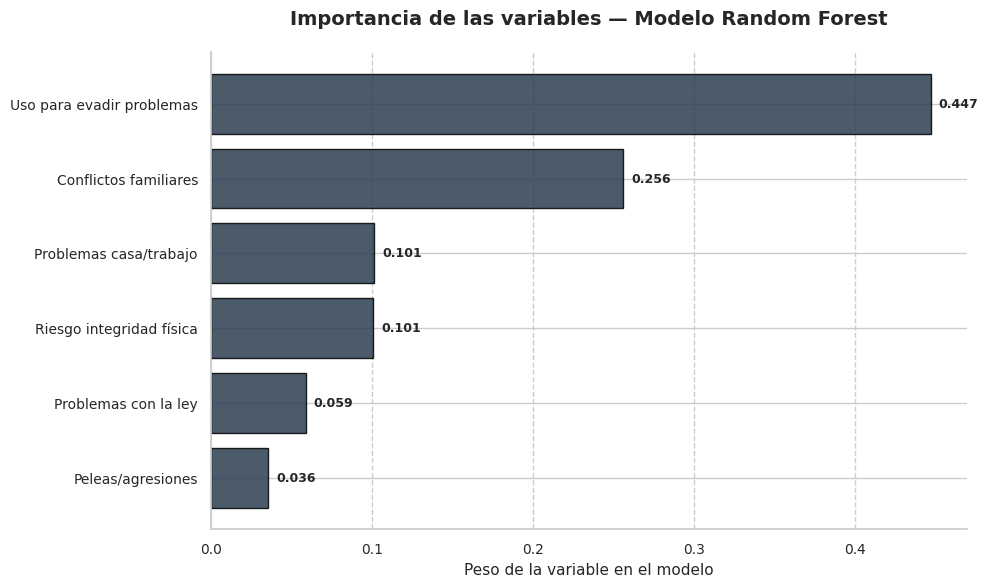

In [49]:
rf_model = resultados['Random Forest']['modelo']
importancias = pd.Series(rf_model.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(importancias.index, importancias.values, color='#2c3e50', edgecolor='black', alpha=0.85)

ax.set_title('Importancia de las variables — Modelo Random Forest', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Peso de la variable en el modelo', fontsize=11)

ax.set_yticklabels([etiquetas.get(v, v) for v in importancias.index], fontsize=10)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', fontsize=9, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', color='grey', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('importancia_variables_pro.png', dpi=300, bbox_inches='tight')
plt.show()